<a href="https://colab.research.google.com/github/Abhishek-Prashant-Chandurkar/EPR_BUJSO/blob/main/task_scheduling_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Workload Prioritization and Optimal Task Scheduling (Simplified BUJSO)

This notebook implements:
- Synthetic dataset generation
- K-means clustering
- AHP-based ranking
- Multi-objective scheduling
- Simplified hybrid optimization (BUJSO-inspired)


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import random

np.random.seed(42)


## Generate Synthetic Tasks

In [ ]:

def generate_tasks(n_tasks=100):
    data = {
        "task_id": np.arange(n_tasks),  # Assign task ids to each task
        "execution_time": np.random.uniform(1, 100, n_tasks),   # Execution time is in the range [1,100] with uiform distribution
        "cpu": np.random.uniform(0.1, 1.0, n_tasks), # Fraction of CPU core (normalised CPU util)
        "memory": np.random.uniform(128, 2048, n_tasks), # Memory in MBs
        "security": np.random.uniform(0, 3, n_tasks) # Higher score means less risk
    }
    return pd.DataFrame(data)

tasks = generate_tasks(100)
tasks.head()


,task_id,execution_time,cpu,memory,security
0,0,38.079472,0.128286,1360.700761,0.155045
1,1,95.120716,0.672769,289.548733,1.594064
2,2,73.467400,0.382920,438.327131,1.621905
3,3,60.267190,0.557714,1853.224042,1.912290
4,4,16.445845,0.916810,1292.343795,2.178274


## K-Means Clustering

In [ ]:

def cluster_tasks(tasks, k=4):
    features = tasks[["execution_time", "cpu", "memory"]]  # The features used to make clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    tasks["cluster"] = kmeans.fit_predict(features)
    return tasks

tasks = cluster_tasks(tasks)


## AHP Ranking

In [ ]:

def ahp_ranking(tasks):
    norm = tasks[["execution_time", "cpu", "memory"]]
    norm = (norm - norm.min()) / (norm.max() - norm.min())
    weights = np.array([0.5, 0.3, 0.2])
    scores = norm.values @ weights
    tasks["priority_score"] = scores
    tasks["rank"] = tasks["priority_score"].rank(ascending=False)
    return tasks

tasks = ahp_ranking(tasks)


## Generate Virtual Machines

In [ ]:

def generate_vms(n_vms=10):
    vms = []
    for i in range(n_vms):
        vms.append({
            "vm_id": i,
            "cpu_capacity": np.random.uniform(1, 4), # No. of CPU cores
            "memory_capacity": np.random.uniform(2048, 8192)
        })
    return pd.DataFrame(vms)

vms = generate_vms(10)


## Objective Functions

In [ ]:
# Total Completion Time of all tasks
def makespan(schedule):
    return max(schedule.values())

def utilization_cost(task, vm):
    return abs(task["cpu"] - vm["cpu_capacity"])

# Network Overhead, etc.
def migration_cost(task):
    return random.uniform(0.1, 1.0)

def risk_probability(sec):
    if sec <= 0:
        return 1
    elif sec <= 1:
        return 1 - np.exp(-1.5 * sec)
    elif sec <= 2:
        return 1 - np.exp(-0.5 * sec)
    else:
        return 0


## Fitness Function

In [ ]:

def fitness(schedule, tasks, vms):
    P1 = makespan(schedule)
    P2 = sum(abs(tasks.iloc[i]["cpu"] - vms.iloc[schedule[i]]["cpu_capacity"]) for i in range(len(tasks)))
    P3 = sum(random.uniform(0.1, 1.0) for _ in range(len(tasks)))
    P4 = sum(risk_probability(tasks.iloc[i]["security"]) for i in range(len(tasks)))
    return 0.4*P1 + 0.2*P2 + 0.2*P3 + 0.2*P4


## Optimization

In [ ]:

def optimize(tasks, vms, iterations=50, pop_size=10):
    best_solution = None
    best_score = float("inf")

    for _ in range(pop_size):
        schedule = {i: random.randint(0, len(vms)-1) for i in range(len(tasks))}

        for t in range(iterations):
            new_schedule = schedule.copy()
            i = random.randint(0, len(tasks)-1)
            new_schedule[i] = random.randint(0, len(vms)-1)

            score = fitness(new_schedule, tasks, vms)

            if score < best_score:
                best_score = score
                best_solution = new_schedule

            schedule = new_schedule

    return best_solution, best_score

best_schedule, best_score = optimize(tasks, vms)
print("Best Fitness:", best_score)


Best Fitness: 56.37936963108733


## Visualization

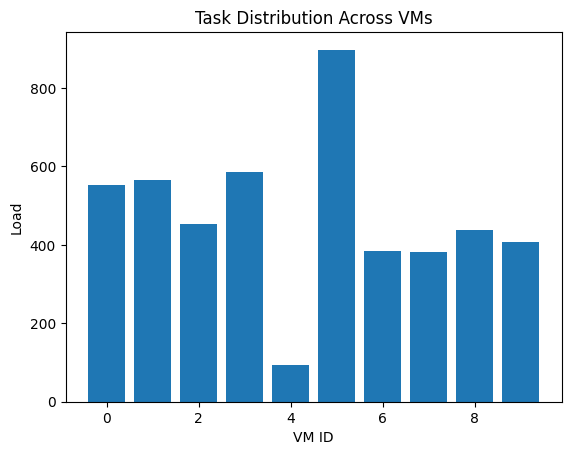

In [ ]:

vm_loads = [0]*len(vms)

for task_id, vm_id in best_schedule.items():
    vm_loads[vm_id] += tasks.iloc[task_id]["execution_time"]

plt.bar(range(len(vms)), vm_loads)
plt.xlabel("VM ID")
plt.ylabel("Load")
plt.title("Task Distribution Across VMs")
plt.show()
